# RMU Sweep Analysis

Analyze hyperparameter sweep results and find top configurations.

In [53]:
import json
import os
from pathlib import Path
from dataclasses import dataclass
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [69]:
# Configuration
SWEEP_DIR = Path("models/sweep")
K = 3  # Top K results to show

# Baseline Gemma-2-9b-it results (from earlier evaluation)
mmlu_results_path = Path("/mnt/align4_drive2/adrianoh/git/SAEScoping/baselines/wmdp_github_main/eval_results/gemma2_9b_baseline_mmlu/results.json")
mmlu_results = json.loads(mmlu_results_path.read_text())["results"]
mmlu_acc = mmlu_results["mmlu"]["acc,none"]

# Should be around 50% ^
# acc. to TIGER Lab this is kind of OK: https://huggingface.co/spaces/TIGER-Lab/MMLU-Pro

print(mmlu_acc)
BASELINE = {
    "run_name": "baseline (no RMU)",
    # TODO is this correct? Adriano should please verify what LLM found
    "wmdp_acc": 0.4318,
    "wmdp_bio_acc": 0.5098,
    "wmdp_cyber_acc": 0.3915,
    "wmdp_chem_acc": 0.3848,
    "mmlu_acc": mmlu_acc, # around 70% acc. to paper with 5 shot; 
    "steering_coeff": None,
    "alpha": None,
    "layer_id": None,
}

# Metric: 1 - mean_wmdp + mmlu (rewards low WMDP, high MMLU)
def compute_metric(result: dict) -> float:
    """Compute ranking metric. Higher is better."""
    wmdp_acc = result.get("wmdp_acc")
    mmlu_acc = result.get("mmlu_acc")
    
    if wmdp_acc is None:
        return float("-inf")
    
    # If MMLU not available, just use WMDP (penalized)
    if mmlu_acc is None:
        mmlu_acc = 0.0
    
    # Metric: (1 - wmdp) + mmlu
    # Low WMDP (good unlearning) + High MMLU (preserved capabilities)
    return 1 / (1 / (1 - wmdp_acc) + 1 / mmlu_acc)

0.5004272895598918


In [64]:
def load_all_results(sweep_dir: Path) -> list[dict]:
    """Load all results from sweep directory."""
    results = []
    
    for run_dir in sweep_dir.iterdir():
        if not run_dir.is_dir():
            continue
        
        result = {"run_name": run_dir.name}
        
        # Load WMDP results
        wmdp_file = run_dir / "eval" / "results.json"
        if wmdp_file.exists():
            with open(wmdp_file) as f:
                wmdp_data = json.load(f)
            result["wmdp_acc"] = wmdp_data["results"]["wmdp"]["acc,none"]
            result["wmdp_bio_acc"] = wmdp_data["results"]["wmdp_bio"]["acc,none"]
            result["wmdp_cyber_acc"] = wmdp_data["results"]["wmdp_cyber"]["acc,none"]
            result["wmdp_chem_acc"] = wmdp_data["results"]["wmdp_chem"]["acc,none"]
        
        # Load MMLU results
        mmlu_file = run_dir / "eval_mmlu" / "results.json"
        if mmlu_file.exists():
            with open(mmlu_file) as f:
                mmlu_data = json.load(f)
            result["mmlu_acc"] = mmlu_data["results"]["mmlu"]["acc,none"]
        
        # Parse hyperparameters from run name
        # Format: gemma_2_9b_it_sc{sc}_a{alpha}_l{layer}_lr{lr}
        parts = run_dir.name.split("_")
        for part in parts:
            if part.startswith("sc"):
                result["steering_coeff"] = int(part[2:])
            elif part.startswith("a") and part[1:].isdigit():
                result["alpha"] = int(part[1:])
            elif part.startswith("l") and part[1:].isdigit():
                result["layer_id"] = int(part[1:])
        
        if "wmdp_acc" in result:  # Only include completed runs
            results.append(result)
    
    return results

In [65]:
# Load results
results = load_all_results(SWEEP_DIR)
print(f"Loaded {len(results)} completed runs")

# Compute metric for each
for r in results:
    r["metric"] = compute_metric(r)

# Sort by metric (higher is better)
results_sorted = sorted(results, key=lambda x: x["metric"], reverse=True)

# Convert to DataFrame for display
df = pd.DataFrame(results_sorted)
print(f"\nTop {K} runs by metric (1 - WMDP + MMLU):")
display_cols = ["run_name", "metric", "wmdp_acc", "wmdp_bio_acc", "wmdp_cyber_acc", "wmdp_chem_acc", "mmlu_acc", "steering_coeff", "alpha", "layer_id"]
display_cols = [c for c in display_cols if c in df.columns]
df[display_cols].head(K)

Loaded 33 completed runs


ZeroDivisionError: float division by zero

In [66]:
# Get top K results
top_k = results_sorted[:K]

print(f"Top {K} Configurations:")
print("=" * 90)
for i, r in enumerate(top_k, 1):
    print(f"\n#{i}: {r['run_name']}")
    print(f"    Metric: {r['metric']:.4f}")
    print(f"    WMDP (avg): {r.get('wmdp_acc', 0):.4f}" if r.get('wmdp_acc') else "    WMDP:   N/A")
    print(f"      - Bio:   {r.get('wmdp_bio_acc', 0):.4f}" if r.get('wmdp_bio_acc') else "      - Bio:   N/A")
    print(f"      - Cyber: {r.get('wmdp_cyber_acc', 0):.4f}" if r.get('wmdp_cyber_acc') else "      - Cyber: N/A")
    print(f"      - Chem:  {r.get('wmdp_chem_acc', 0):.4f}" if r.get('wmdp_chem_acc') else "      - Chem:  N/A")
    print(f"    MMLU:   {r.get('mmlu_acc', 0):.4f}" if r.get('mmlu_acc') else "    MMLU:   N/A")
    print(f"    Hyperparams: sc={r.get('steering_coeff')}, alpha={r.get('alpha')}, layer={r.get('layer_id')}")

Top 3 Configurations:

#1: gemma_2_9b_it_sc200_a50_l10_lr5e-05
    Metric: 1.1556
    WMDP (avg): 0.3231
      - Bio:   0.3504
      - Cyber: 0.3025
      - Chem:  0.3382
    MMLU:   0.4787
    Hyperparams: sc=200, alpha=50, layer=10

#2: gemma_2_9b_it_sc300_a50_l7_lr5e-05
    Metric: 1.1427
    WMDP (avg): 0.3152
      - Bio:   0.3661
      - Cyber: 0.2869
      - Chem:  0.2941
    MMLU:   0.4578
    Hyperparams: sc=300, alpha=50, layer=7

#3: gemma_2_9b_it_sc100_a50_l10_lr5e-05
    Metric: 1.1343
    WMDP (avg): 0.3293
      - Bio:   0.3778
      - Cyber: 0.2999
      - Chem:  0.3211
    MMLU:   0.4637
    Hyperparams: sc=100, alpha=50, layer=10


In [67]:
def plot_run_comparison(top_k: list[dict], baseline: dict = BASELINE):
    """Plot comparison of top K runs and baseline, with WMDP and MMLU barplots."""
    # Add baseline to comparison
    runs_to_plot = [baseline] + top_k

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    run_names = [
        r["run_name"].replace("gemma_2_9b_it_", "").replace("baseline (no RMU)", "BASELINE")
        for r in runs_to_plot
    ]
    colors = ["#e74c3c"] + list(plt.cm.viridis(np.linspace(0.2, 0.8, len(top_k))))  # Red for baseline

    # Plot 1: WMDP breakdown (Bio, Cyber, Chem, Avg)
    ax1 = axes[0]
    x = np.arange(len(runs_to_plot))
    width = 0.2

    wmdp_bio = [r.get("wmdp_bio_acc", 0) for r in runs_to_plot]
    wmdp_cyber = [r.get("wmdp_cyber_acc", 0) for r in runs_to_plot]
    wmdp_chem = [r.get("wmdp_chem_acc", 0) for r in runs_to_plot]
    wmdp_avg = [r.get("wmdp_acc", 0) for r in runs_to_plot]

    ax1.bar(x - 1.5 * width, wmdp_bio, width, label="Bio", color="#c0392b", alpha=0.8)
    ax1.bar(x - 0.5 * width, wmdp_cyber, width, label="Cyber", color="#2980b9", alpha=0.8)
    ax1.bar(x + 0.5 * width, wmdp_chem, width, label="Chem", color="#27ae60", alpha=0.8)
    ax1.bar(x + 1.5 * width, wmdp_avg, width, label="Avg", color="#8e44ad", alpha=0.8)

    ax1.axhline(y=0.25, color="gray", linestyle="--", linewidth=1.5, label="Random (25%)")
    ax1.set_ylabel("Accuracy")
    ax1.set_title("WMDP Performance (Lower = Better Unlearning)")
    ax1.set_xticks(x)
    ax1.set_xticklabels(run_names, rotation=45, ha="right", fontsize=8)
    ax1.legend(loc="upper right", fontsize=7)
    ax1.set_ylim(0, 0.6)
    ax1.axvspan(-0.5, 0.5, alpha=0.1, color="red")  # Highlight baseline

    # Plot 2: MMLU as individual bar for each run
    ax2 = axes[1]
    mmlu_vals = [r.get("mmlu_acc", 0) or 0 for r in runs_to_plot]
    bars = ax2.bar(run_names, mmlu_vals, color=colors, edgecolor="black", linewidth=0.7)
    ax2.set_ylabel("Accuracy")
    ax2.set_title("MMLU Performance (Higher = Better Retention)")
    ax2.set_ylim(0, max(0.6, max(mmlu_vals) + 0.05))
    ax2.tick_params(axis="x", rotation=45)
    plt.setp(ax2.get_xticklabels(), fontsize=8, ha="right")
    # Add value labels on MMLU bars
    for bar, val in zip(bars, mmlu_vals):
        if val != 0:
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{val:.1%}", ha="center", va="bottom", fontsize=8)
        else:
            ax2.text(bar.get_x() + bar.get_width() / 2, 0.01, "N/A", ha="center", va="bottom", fontsize=7, color="#888")

    plt.tight_layout()
    plt.savefig(SWEEP_DIR / "top_k_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to {SWEEP_DIR / 'top_k_analysis.png'}")

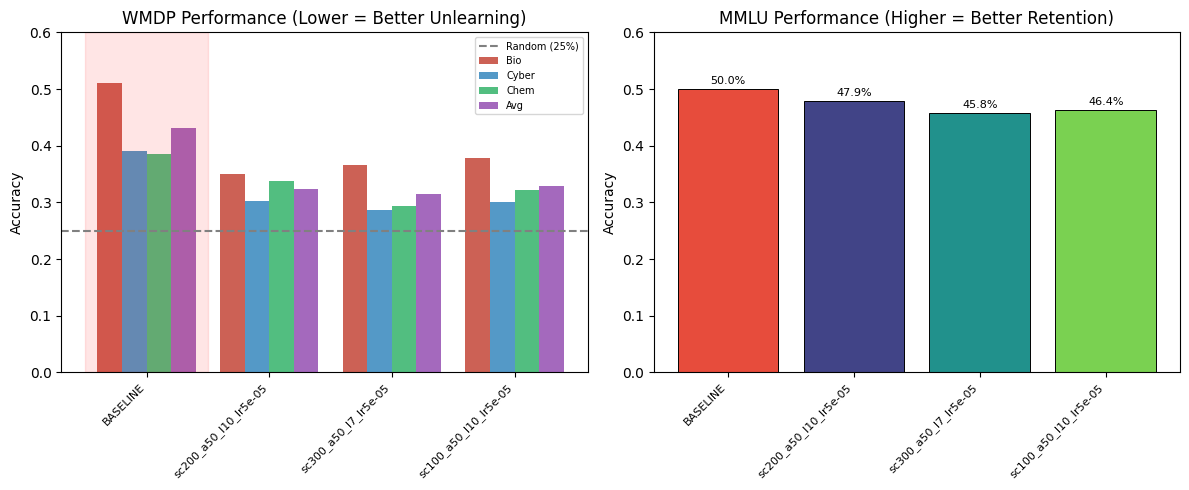

Saved plot to models/sweep/top_k_analysis.png


In [68]:
# Plot top K runs
if len(top_k) > 0:
    plot_run_comparison(top_k)
else:
    print("No completed runs to plot yet.")

In [60]:
def plot_hyperparameter_heatmap(results: list[dict]):
    """Plot heatmap of metric across hyperparameters."""
    if len(results) < 2:
        print("Not enough results for heatmap")
        return
    
    df = pd.DataFrame(results)
    
    # Check which columns exist
    if "steering_coeff" not in df.columns or "alpha" not in df.columns:
        print("Missing hyperparameter columns")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Group by layer_id and create heatmaps
    layer_ids = sorted(df["layer_id"].unique()) if "layer_id" in df.columns else [None]
    
    for idx, layer_id in enumerate(layer_ids[:3]):  # Max 3 subplots
        ax = axes[idx] if len(layer_ids) > 1 else axes[0]
        
        if layer_id is not None:
            subset = df[df["layer_id"] == layer_id]
            title = f"Layer {layer_id}"
        else:
            subset = df
            title = "All Layers"
        
        if len(subset) == 0:
            continue
        
        pivot = subset.pivot_table(
            values="metric", 
            index="alpha", 
            columns="steering_coeff",
            aggfunc="mean"
        )
        
        im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("Steering Coefficient")
        ax.set_ylabel("Alpha")
        ax.set_title(title)
        
        # Add value annotations
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
        
        plt.colorbar(im, ax=ax, label="Metric")
    
    # Hide unused axes
    for idx in range(len(layer_ids), 3):
        axes[idx].axis("off")
    
    plt.suptitle("Metric Heatmap: (1 - WMDP) + MMLU", fontsize=12)
    plt.tight_layout()
    plt.savefig(SWEEP_DIR / "hyperparameter_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved heatmap to {SWEEP_DIR / 'hyperparameter_heatmap.png'}")

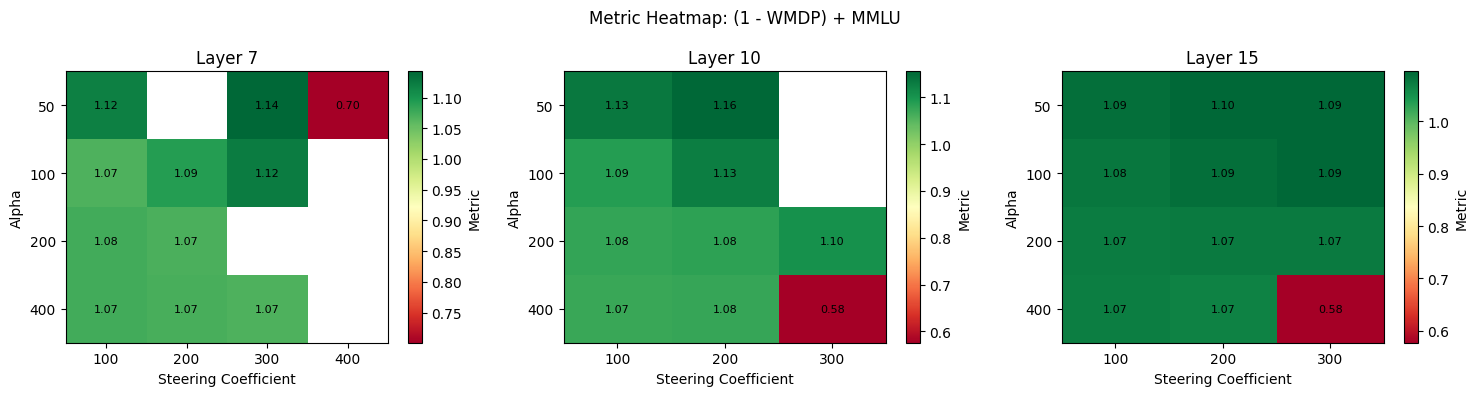

Saved heatmap to models/sweep/hyperparameter_heatmap.png


In [61]:
# Plot hyperparameter heatmap
if len(results) >= 2:
    plot_hyperparameter_heatmap(results)
else:
    print("Need at least 2 results for heatmap.")

In [62]:
# Full results table with WMDP breakdown
print("\nAll Results (sorted by metric):")
full_cols = ["run_name", "metric", "wmdp_acc", "wmdp_bio_acc", "wmdp_cyber_acc", "wmdp_chem_acc", "mmlu_acc", "steering_coeff", "alpha", "layer_id"]
full_cols = [c for c in full_cols if c in df.columns]
df_display = df[full_cols].copy() if len(df) > 0 else pd.DataFrame()
if len(df_display) > 0:
    # Format for better readability
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    df_display


All Results (sorted by metric):
